/tmp/ipykernel_12137/2244283003.py:8: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv')
/tmp/ipykernel_12137/2244283003.py:22: DtypeWarning: Columns (38) have mixed types. Specify dtype option on import or set low_memory=False.
  full_df = pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv')
/tmp/ipykernel_12137/2244283003.py:142: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([


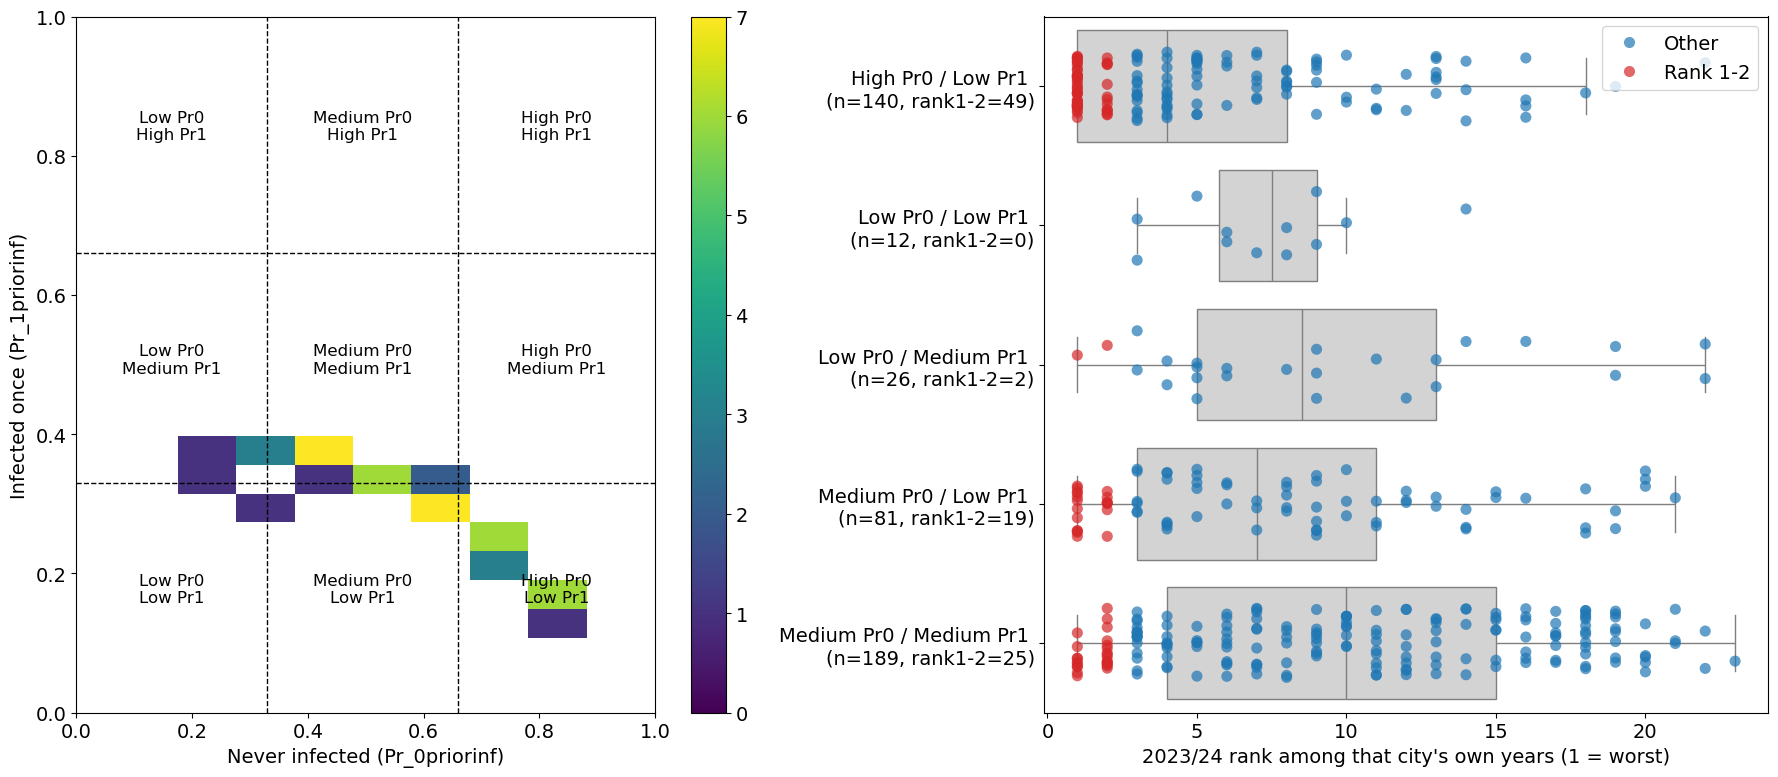

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams.update({'font.size': 14})

df = pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv')
df = df[(df['region'] == 'North') & (df['year'] == 2024)]

crosswalk       = pd.read_csv('data/code_health_region_to_city_residency.csv')
immunity_region = pd.read_csv('data/immunity_posterior_mean_region.csv')

df = df.merge(crosswalk, on='city_residency', how='left')
df = df.merge(
    immunity_region,
    on=['code_health_region', 'year'],
    how='left',
    suffixes=('', '_health_region')
)

full_df = pd.read_csv('data/model_input_brazil_immunity_city_with_priorinf.csv')

city_year_incidence = full_df.groupby(['city_residency', 'year']).agg(
    n_cases=('n_cases', 'sum'),
    population=('population', 'mean')
).reset_index()
city_year_incidence['incidence_per100k'] = (
    city_year_incidence['n_cases'] / city_year_incidence['population'] * 100000
)
city_year_incidence['year_rank'] = (
    city_year_incidence.groupby('city_residency')['incidence_per100k']
    .rank(ascending=False, method='min')
    .astype(int)
)

df = df.drop(columns=['year_rank'], errors='ignore').merge(
    city_year_incidence[['city_residency', 'year', 'year_rank']],
    on=['city_residency', 'year'],
    how='left'
)

# Fixed absolute cutpoints (0.33, 0.66) instead of data-driven tertiles.
bins = [0, 0.33, 0.66, 1]
labels = ['Low', 'Medium', 'High']

region_immunity = df.drop_duplicates('code_health_region')[
    ['code_health_region', 'Pr_0priorinf_health_region', 'Pr_1priorinf_health_region']
].copy()

region_immunity['pr0_tertile'] = pd.cut(
    region_immunity['Pr_0priorinf_health_region'], bins=bins, labels=labels, include_lowest=True
)
region_immunity['pr1_tertile'] = pd.cut(
    region_immunity['Pr_1priorinf_health_region'], bins=bins, labels=labels, include_lowest=True
)
region_immunity['group'] = (
    region_immunity['pr0_tertile'].astype(str) + ' Pr0 / ' + region_immunity['pr1_tertile'].astype(str) + ' Pr1'
)

df = df.drop(columns=['pr0_tertile', 'pr1_tertile', 'group'], errors='ignore').merge(
    region_immunity[['code_health_region', 'pr0_tertile', 'pr1_tertile', 'group']],
    on='code_health_region', how='left'
)

df_rank = df.drop_duplicates(['city_residency', 'year_rank']).copy()

counts        = df_rank.groupby('group')['city_residency'].nunique()
counts_rank12 = df_rank[df_rank['year_rank'].isin([1, 2])].groupby('group')['city_residency'].nunique()
order = counts.index.tolist()

df_rank['rank_highlight'] = np.where(df_rank['year_rank'].isin([1, 2]), 'Rank 1-2', 'Other')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# --- Left: 2D histogram with fixed grid + quadrant labels (municipality counts) ---
ax = axes[0]

sns.histplot(
    data=df.drop_duplicates('code_health_region'),
    x='Pr_0priorinf_health_region',
    y='Pr_1priorinf_health_region',
    cmap='viridis',
    cbar=True,
    ax=ax
)

for x in [0.33, 0.66]:
    ax.axvline(x, color='k', ls='--', lw=1)
for y in [0.33, 0.66]:
    ax.axhline(y, color='k', ls='--', lw=1)

edges = [0, 0.33, 0.66, 1]
centers = [(edges[i] + edges[i + 1]) / 2 for i in range(3)]

cell_counts = (
    df.drop_duplicates('city_residency')
      .groupby(['pr0_tertile', 'pr1_tertile'], observed=True)['city_residency']
      .nunique()
)

for xi, x_lab in zip(centers, labels):
    for yi, y_lab in zip(centers, labels):
        n = cell_counts.get((x_lab, y_lab), 0)
        ax.text(
            xi, yi, f'{x_lab} Pr0\n{y_lab} Pr1\n',
            ha='center', va='center', fontsize=12, color='black',
        )

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel('Never infected (Pr_0priorinf)')
ax.set_ylabel('Infected once (Pr_1priorinf)')

# --- Right: year-rank distribution by group ---
ax = axes[1]

sns.boxplot(
    x='year_rank',
    y='group',
    data=df_rank,
    order=order,
    showfliers=False,
    color='lightgrey',
    ax=ax
)
sns.stripplot(
    x='year_rank',
    y='group',
    data=df_rank,
    order=order,
    hue='rank_highlight',
    hue_order=['Other', 'Rank 1-2'],
    palette={'Other': 'C0', 'Rank 1-2': 'C3'},
    size=8,
    alpha=0.7,
    jitter=0.25,
    dodge=False,
    ax=ax
)

ax.set_yticklabels([
    f'{g} \n(n={counts[g]}, rank1-2={counts_rank12.get(g, 0)})'
    for g in order
])
ax.set_xlabel('2023/24 rank among that city\'s own years (1 = worst)')
ax.set_ylabel('')
ax.legend(title='', loc='upper right')

plt.tight_layout()
plt.savefig('img/north_immunity_variation.pdf')
plt.show()
